# Eksperyment: Test

Test działania eksperymentów.

In [19]:
import numpy as np
import matplotlib.pyplot as plt
from mlp.mlp import MLP
from mlp.utils import (
    load_dataset, plot_dataset, plot_loss, plot_accuracy, train_test_split, plot_predictions,
    plot_decision_boundary, plot_weights_together, accuracy, mse
)


In [20]:
# === 1. Konfiguracja ===

datasets = {
    # ======== KLASYFIKACJA ========
    # "simple": {
    #     "path": "../lab1_data/Classification/data.simple.train.1000.csv",
    #     "task": "binary",
    #     "losses": ["mse", "binary_cross_entropy"],
    #     "activation": "gelu",
    #     "learning_rate": 0.01,
    #     "hidden_layers": [32, 32],
    #     "epochs": [50, 100],
    # },
    # "three_gauss": {
    #     "path": "../lab1_data/Classification/data.three_gauss.train.1000.csv",
    #     "task": "multiclass",
    #     "losses": ["mse", "categorical_cross_entropy"],
    #     "activation": "gelu",
    #     "learning_rate": 0.01,
    #     "hidden_layers": [32, 32],
    #     "epochs": [50, 100],
    # },
    # "xor": {
    #     "path": "../lab1_data/Classification/data.XOR.train.1000.csv",
    #     "task": "binary",
    #     "losses": ["mse", "binary_cross_entropy"],
    #     "activation": "gelu",
    #     "learning_rate": 0.01,
    #     "hidden_layers": [16, 16],
    #     "epochs": [50, 100],
    # },
    # "noisy_xor": {
    #     "path": "../lab1_data/Classification/data.noisyXOR.train.1000.csv",
    #     "task": "binary",
    #     "losses": ["mse", "binary_cross_entropy"],
    #     "activation": "gelu",
    #     "learning_rate": 0.01,
    #     "hidden_layers": [32, 32],
    #     "epochs": [50, 100],
    # },
    # "circles": {
    #     "path": "../lab1_data/Classification/data.circles.train.1000.csv",
    #     "task": "binary",
    #     "losses": ["mse"],
    #     "activation": "gelu",
    #     "learning_rate": 0.01,
    #     "hidden_layers": [16, 16],
    #     "epochs": [50, 100, 1000],
    #     "momentum": False,
    #     "adaptive_lr": False,
    # },



    "circles": {
        "path": "../lab1_data/Classification/data.circles.train.1000.csv",
        "path_test": "../lab1_data/Classification/data.circles.test.1000.csv",
        "task": "multiclass",
        "losses": ["mse"],
        "activation": "gelu",
        "learning_rate": 0.07,
        "hidden_layers": [32, 32],
        "epochs": [3000],
        "momentum": False,
        "adaptive_lr": False,
    },
    # "circles_with_momentum": {
    #     "path": "../lab1_data/Classification/data.circles.train.1000.csv",
    #     "task": "multiclass",
    #     "losses": ["mse"],
    #     "activation": "gelu",
    #     "learning_rate": 0.1,
    #     "hidden_layers": [32, 32],
    #     "epochs": [3000],
    #     "momentum": True,
    #     "adaptive_lr": False,
    # },
    # "circles_with_adaptive_lr": {
    #     "path": "../lab1_data/Classification/data.circles.train.1000.csv",
    #     "task": "multiclass",
    #     "losses": ["mse"],
    #     "activation": "gelu",
    #     "learning_rate": 0.1,
    #     "hidden_layers": [32, 32],
    #     "epochs": [3000],
    #     "momentum": False,
    #     "adaptive_lr": True,
    # },


    #
    # # ======== REGRESJA ========
    "activation": {
        "path": "../lab1_data/Regression/data.activation.train.1000.csv",
        "path_test": "../lab1_data/Regression/data.activation.test.1000.csv",
        "task": "regression",
        "losses": ["mse", "mae"],
        "activation": "gelu",
        "learning_rate": 0.001,
        "hidden_layers": [32, 32],
        "epochs": [1000],
        "momentum": False,
        "adaptive_lr": False,
    },

    # "cube": {
    #     "path": "../lab1_data/Regression/data.cube.train.1000.csv",
    #     "task": "regression",
    #     "losses": ["mse", "mae"],
    #     "activation": "gelu",
    #     "learning_rate": 0.001,
    #     "hidden_layers": [32, 32],
    #     "epochs": [50, 100],
    # },
    # "linear": {
    #     "path": "../lab1_data/Regression/data.linear.train.1000.csv",
    #     "task": "regression",
    #     "losses": ["mse", "mae"],
    #     "activation": "gelu",
    #     "learning_rate": 0.001,
    #     "hidden_layers": [16],
    #     "epochs": [50, 100],
    # },
    # "square": {
    #     "path": "../lab1_data/Regression/data.square.train.1000.csv",
    #     "task": "regression",
    #     "losses": ["mse", "mae"],
    #     "activation": "gelu",
    #     "learning_rate": 0.001,
    #     "hidden_layers": [32],
    #     "epochs": [50, 100],
    # },
    # "multimodal": {
    #     "path": "../lab1_data/Regression/data.multimodal.train.1000.csv",
    #     "task": "regression",
    #     "losses": ["mse", "mae"],
    #     "activation": "gelu",
    #     "learning_rate": 0.001,
    #     "hidden_layers": [64, 64],
    #     "epochs": [50, 100],
    # },
}


=== Dataset: CIRCLES ===
[load_dataset] Detected CLASSIFICATION: unique labels [0 1 2 3]
[load_dataset] Detected CLASSIFICATION: unique labels [0 1 2 3]


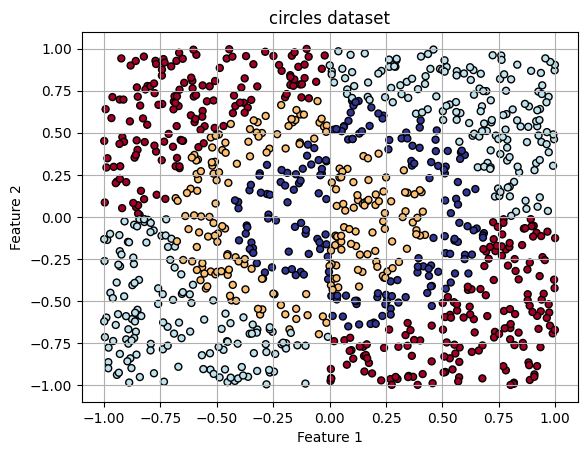


--- Training with loss: mse (3000 epochs) ---


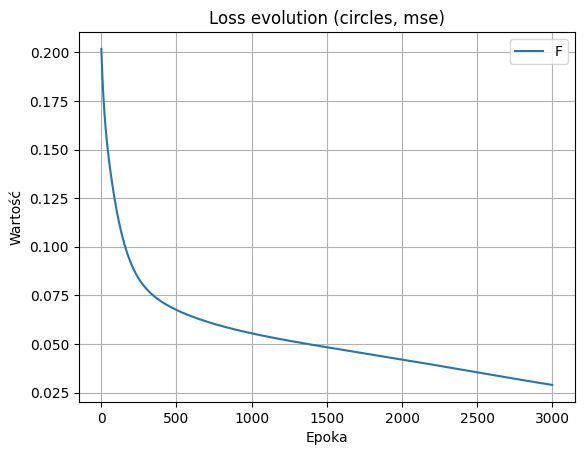

Final test accuracy (mse, 3000 ep): 0.9280


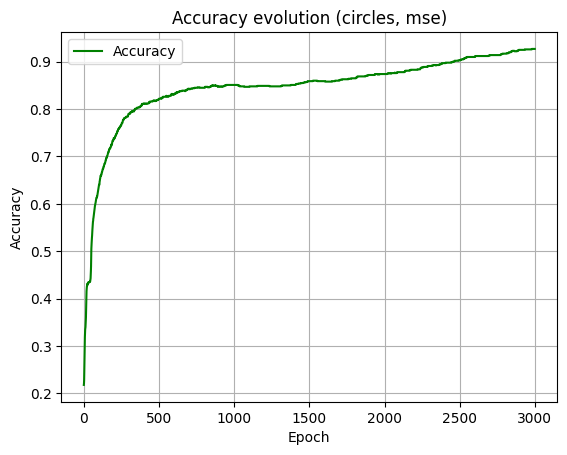

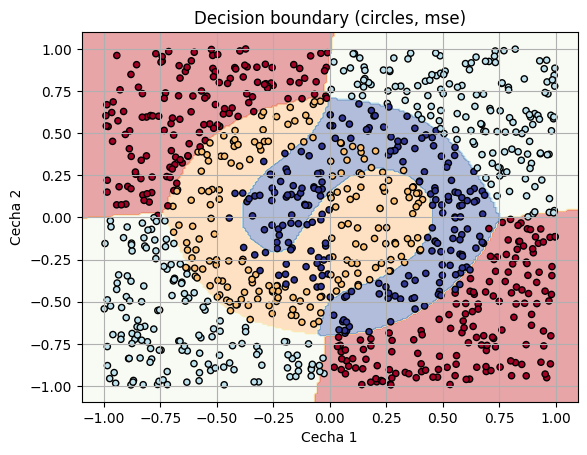


=== Dataset: ACTIVATION ===
[load_dataset] Detected REGRESSION: normalized target (mean=-93.366, std=89.163)
[load_dataset] Detected REGRESSION: normalized target (mean=-125.165, std=120.192)


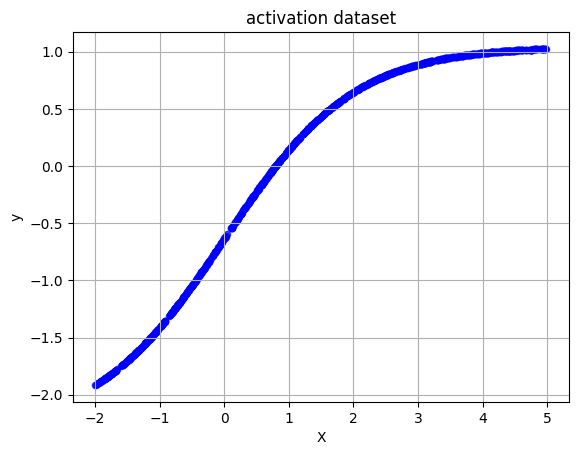


--- Training with loss: mse (1000 epochs) ---


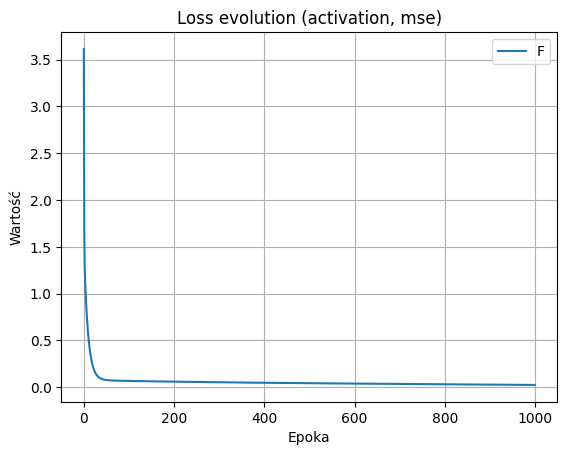

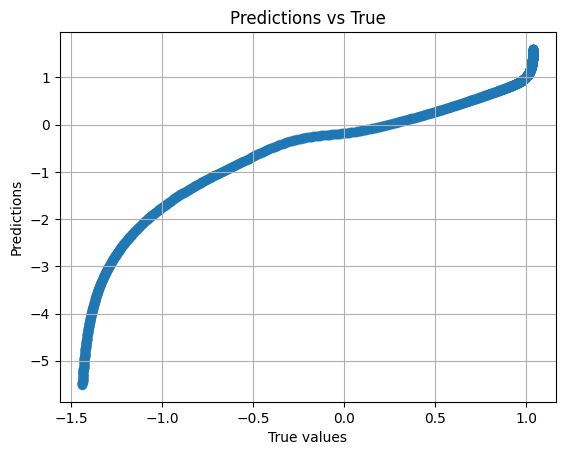

Final test MSE (mse, 1000 ep): 1.8935

--- Training with loss: mae (1000 epochs) ---


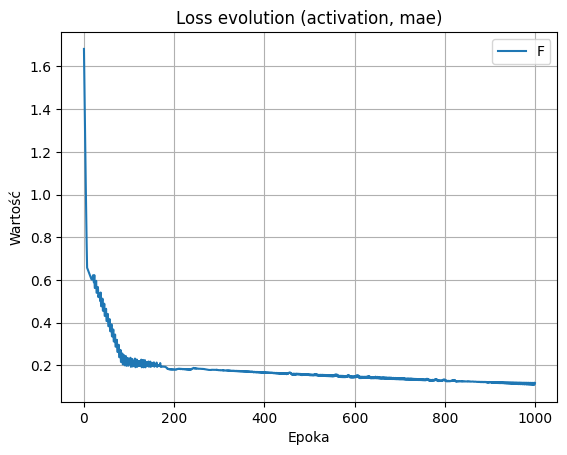

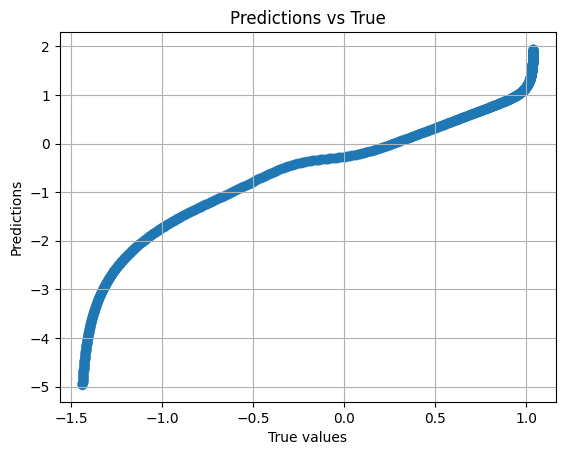

Final test MSE (mae, 1000 ep): 1.4849


In [21]:
# === 2. Eksperyment główny ===
results = {}

for dataset_name, cfg in datasets.items():
    print(f"\n=== Dataset: {dataset_name.upper()} ===")
    X_train, y_train = load_dataset(cfg["path"], verbose=True)
    X_test, y_test = load_dataset(cfg["path_test"], verbose=True)
    plot_dataset(X_train, y_train, title=f"{dataset_name} dataset")

    # X_train, X_test, y_train, y_test = train_test_split(X, y, test_ratio=0.3, seed=42)

    results[dataset_name] = {}

    for loss in cfg["losses"]:
        for epoch_count in cfg["epochs"]:
            print(f"\n--- Training with loss: {loss} ({epoch_count} epochs) ---")
            # print(f"\n--- X.shape[1]: {X.shape[1]}")
            # print(f'\n--- (1 if cfg["task"] != "multiclass" else len(np.unique(y))): {(1 if cfg["task"] != "multiclass" else len(np.unique(y)))}')
            model = MLP(
                layer_sizes=[X_train.shape[1], 32, 32, (1 if cfg["task"] != "multiclass" else len(np.unique(y_train)))],
                # layer_sizes=[1, 32, 32, 1],
                task=cfg["task"],
                # task="regression",
                activation=cfg["activation"],
                learning_rate=cfg["learning_rate"],
                loss=loss,
                seed=42,
                momentum=cfg.get("momentum", False),
                beta=0.9,
                adaptive_lr=cfg.get("adaptive_lr", False),
                lr_decay=0.995,
            )

            history, weight_history, acc_history = model.fit(X_train, y_train, epochs=epoch_count, verbose=False)
            results[dataset_name][loss] = {
                "model": model,
                "loss_history": history,
                "weight_history": weight_history,
                "acc_history": acc_history,
            }

            # --- Wizualizacje ---
            plot_loss(history, title=f"Loss evolution ({dataset_name}, {loss})")
            # plot_weights_together(weight_history, title=f"Weight evolution ({dataset_name}, {loss})")

            if cfg["task"] in ["binary", "multiclass"]:
                preds = model.predict(X_test)
                acc_val = accuracy(y_test, preds)
                print(f"Final test accuracy ({loss}, {epoch_count} ep): {acc_val:.4f}")
                plot_accuracy(acc_history, title=f"Accuracy evolution ({dataset_name}, {loss})")
                plot_decision_boundary(model, X_test, y_test, title=f"Decision boundary ({dataset_name}, {loss})")
            else:
                y_pred = model.predict(X_test)
                mse_val = mse(y_test, y_pred)
                plot_predictions(y_test, y_pred)
                print(f"Final test MSE ({loss}, {epoch_count} ep): {mse_val:.4f}")

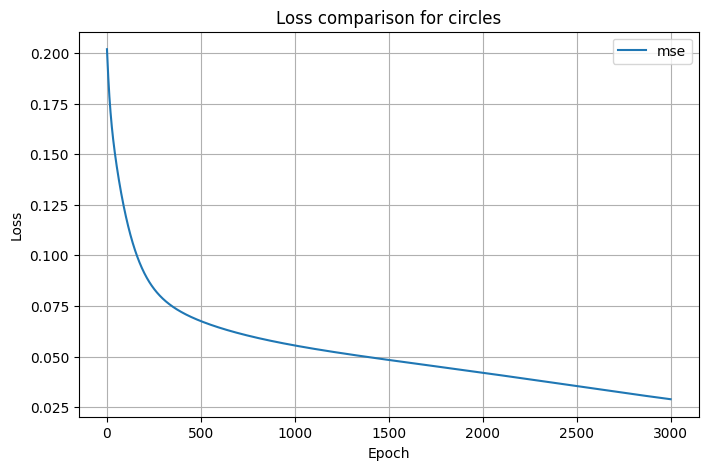

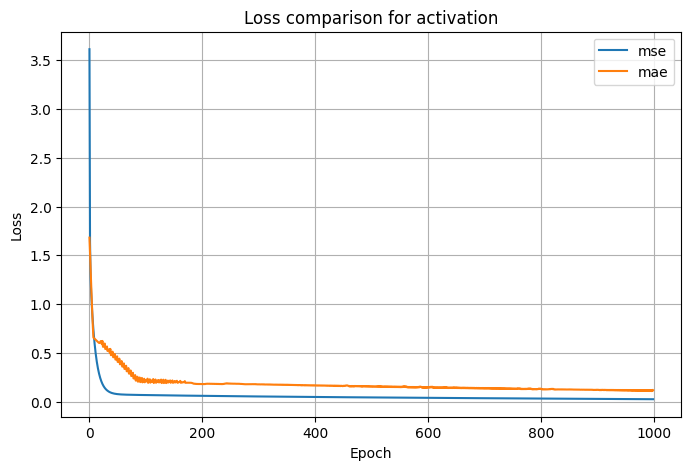

In [22]:
# === 3. Porównanie funkcji strat w obrębie zbioru ===
for dataset_name, res in results.items():
    plt.figure(figsize=(8, 5))
    for loss, data in res.items():
        plt.plot(data["loss_history"], label=loss)
    plt.title(f"Loss comparison for {dataset_name}")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend()
    plt.grid(True)
    plt.show()